In [ ]:
import numpy as np
import sys, os
from scipy.interpolate import make_interp_spline
from SpaceBalls.sph_meshing import RegularLatLonGrid, QuadratureGrid
from SpaceBalls.radiation_fluxes_preprocessing import compute_daily_hist_at_sat_r_hist
import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.plotter import Plotter
import config.constants as constants
import itertools
import random
import time
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR, INPUT_DIR, OUTPUT_DIR
lebedev_n_array = [41, 47, 53, 59, 65, 71, 77, 83,
                    89, 95, 101, 107, 113, 119, 125, 131]

EEI_name = "EEI_truth_1"
base_sb_tag = 'LAGEOS'
n_days_arc = 1
n_propagations = 20

"""
true_r_hist = np.vstack([np.load(os.path.join(OUTPUT_DIR, base_sb_tag + '_' + str(100+n_propagations-1), 
                         'day_'+str(day_idx), 'xyz_ecef.npy')) for day_idx in range(n_days_arc)]) # finest propagation in MONTE 
jd_hist = np.vstack([np.load(os.path.join(OUTPUT_DIR, base_sb_tag + '_' + str(100+n_propagations-1), 
                         'day_'+str(day_idx), 'jd_vec.npy')) for day_idx in range(n_days_arc)]) # finest propagation in MONTE 
"""

finest_regular_grid = RegularLatLonGrid(0, n_lat=180*10, n_lon=360*10)
regular_grids = [RegularLatLonGrid(0,  n_lat=int(np.round(180*f)), 
                                            n_lon=int(np.round(360*f))) for f in np.logspace(-1, 0.2, 10)]
lebedev_grids = [QuadratureGrid(0, order=o) for o in lebedev_n_array]
womersley_grids = [QuadratureGrid(0, order=o, default_womersley=True) for o in np.arange(41, 325, 4)]

all_Fr_error_time_series_regular = [[] for _ in range(len(regular_grids))]
all_Fr_error_time_series_womersley = [[] for _ in range(len(womersley_grids))]
all_Fr_error_time_series_lebedev =  [[] for _ in range(len(lebedev_grids))]

for day_idx in range(n_days_arc):

    true_r_hist = np.load(os.path.join(OUTPUT_DIR, base_sb_tag + '_' + str(100+n_propagations-1), 
                         'day_'+str(day_idx), 'xyz_ecef.npy'))
    jd_hist = np.load(os.path.join(OUTPUT_DIR, base_sb_tag + '_' + str(100+n_propagations-1), 
                         'day_'+str(day_idx), 'jd_vec.npy'))
    spline = make_interp_spline(jd_hist, true_r_hist)

    new_step_sec = 120
    new_step_days = new_step_sec / (24 * 3600)
    jd_hist = np.arange(jd_hist[0], jd_hist[-1], new_step_days)
    true_r_hist = spline(jd_hist, extrapolate=True)

    t1 = time.time()
    erp_Fr, srp_Fr = compute_daily_hist_at_sat_r_hist(
    EEI_name, true_r_hist, jd_hist, day_idx, toa_grid=QuadratureGrid(0, order=131))
    t2 = time.time()
    print(f"Computation time with Lebedev 131: {t2 - t1}")
    
    true_erp_Fr, true_srp_Fr = compute_daily_hist_at_sat_r_hist(
        EEI_name, true_r_hist, jd_hist, day_idx, toa_grid=finest_regular_grid)
    
    for i, grid in enumerate(regular_grids):
        print(i)
        erp_Fr, srp_Fr = compute_daily_hist_at_sat_r_hist(
            EEI_name, true_r_hist, jd_hist, day_idx, toa_grid=grid)
        all_Fr_error_time_series_regular[i].append(erp_Fr - true_erp_Fr)

    for i, grid in enumerate(womersley_grids):
        erp_Fr, srp_Fr = compute_daily_hist_at_sat_r_hist(
            EEI_name, true_r_hist, jd_hist, day_idx, toa_grid=grid)
        all_Fr_error_time_series_womersley[i].append(erp_Fr - true_erp_Fr)
    
    for i, grid in enumerate(lebedev_grids):
        erp_Fr, srp_Fr = compute_daily_hist_at_sat_r_hist(
            EEI_name, true_r_hist, jd_hist, day_idx, toa_grid=grid)
        all_Fr_error_time_series_lebedev[i].append(erp_Fr - true_erp_Fr)

n_points_regular = np.zeros(len(regular_grids))
for i, grid in enumerate(regular_grids):
    all_Fr_error_time_series_regular[i] = np.concatenate(all_Fr_error_time_series_regular[i])
    n_points_regular[i] = grid.n_points

n_points_womersley = np.zeros(len(womersley_grids))
for i, grid in enumerate(womersley_grids):
    all_Fr_error_time_series_womersley[i] = np.concatenate(all_Fr_error_time_series_womersley[i])
    n_points_womersley[i] = grid.n_points

n_points_lebedev = np.zeros(len(lebedev_grids))
for i, grid in enumerate(lebedev_grids):
    all_Fr_error_time_series_lebedev[i] = np.concatenate(all_Fr_error_time_series_lebedev[i])
    n_points_lebedev[i] = grid.n_points




Loading daily hist TOA...
Computation time with Lebedev 131: 0.09827518463134766


/home/llbu9955/Space-Balls-MST/sbfinal-master/src/SpaceBalls/sph_meshing.py:753: RuntimeWarning: divide by zero encountered in scalar divide
  cos_beta = Re / np.linalg.norm(r_vec)
/home/llbu9955/Space-Balls-MST/sbfinal-master/src/SpaceBalls/sph_meshing.py:705: RuntimeWarning: invalid value encountered in divide
  r_vec_aux = Re * r_vec/r_vec_norm
/home/llbu9955/Space-Balls-MST/sbfinal-master/src/SpaceBalls/sph_meshing.py:714: RuntimeWarning: invalid value encountered in scalar subtract
  ring_area = 2*np.pi*(cos_phi_up-cos_phi_down) * (Re)**2
/home/llbu9955/Space-Balls-MST/sbfinal-master/src/SpaceBalls/sph_meshing.py:719: RuntimeWarning: invalid value encountered in divide
  r_vec_aux = Re/(np.mean([cos_phi_vec[i], cos_phi_vec[i+1]])) * r_vec/r_vec_norm


17557
17958
17578
Evaluating a/e SH maps on TOA grid...
Expanding albedo map (normalization unnorm)...
Computing step 1/5760
Computing step 2/5760
Computing step 3/5760
Computing step 4/5760
Computing step 5/5760
Computing step 6/5760
Computing step 7/5760
Computing step 8/5760
Computing step 9/5760
Computing step 10/5760
Computing step 11/5760
Computing step 12/5760
Computing step 13/5760
Computing step 14/5760
Computing step 15/5760
Computing step 16/5760
Computing step 17/5760
Computing step 18/5760
Computing step 19/5760
Computing step 20/5760
Computing step 21/5760
Computing step 22/5760
Computing step 23/5760
Computing step 24/5760
Computing step 25/5760
Computing step 26/5760
Computing step 27/5760
Computing step 28/5760
Computing step 29/5760
Computing step 30/5760
Computing step 31/5760
Computing step 32/5760
Computing step 33/5760
Computing step 34/5760
Computing step 35/5760
Computing step 36/5760
Computing step 37/5760
Computing step 38/5760
Computing step 39/5760
Computing

/media/monte_share/conda_envs/dataproc/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in func (vectorized)
  outputs = ufunc(*args, out=...)


Computing step 1/5760
Recompute expanded a/e maps
Expanding albedo map (normalization unnorm)...
Computing step 2/5760
Recompute expanded a/e maps
Expanding albedo map (normalization unnorm)...
Computing step 3/5760
Recompute expanded a/e maps
Expanding albedo map (normalization unnorm)...
Computing step 4/5760
Recompute expanded a/e maps
Expanding albedo map (normalization unnorm)...
Computing step 5/5760
Recompute expanded a/e maps
Expanding albedo map (normalization unnorm)...
Computing step 6/5760
Recompute expanded a/e maps
Expanding albedo map (normalization unnorm)...
Computing step 7/5760
Recompute expanded a/e maps
Expanding albedo map (normalization unnorm)...
Computing step 8/5760
Recompute expanded a/e maps
Expanding albedo map (normalization unnorm)...
Computing step 9/5760
Recompute expanded a/e maps
Expanding albedo map (normalization unnorm)...
Computing step 10/5760
Recompute expanded a/e maps
Expanding albedo map (normalization unnorm)...
Computing step 11/5760
Recomp

/tmp/ipykernel_507011/222349839.py:106: RuntimeWarning: invalid value encountered in divide
  all_rel_diffs_erp[i] = diff / recomp_erp_Fr_hist
/tmp/ipykernel_507011/222349839.py:112: RuntimeWarning: divide by zero encountered in divide
  all_rel_diffs_srp[i] = diff / recomp_srp_Fr_hist
/tmp/ipykernel_507011/222349839.py:112: RuntimeWarning: invalid value encountered in divide
  all_rel_diffs_srp[i] = diff / recomp_srp_Fr_hist


(<Figure size 1920x560 with 1 Axes>,
 <Axes: ylabel='MONTE vs. recomputed $F_R$ (%)'>)

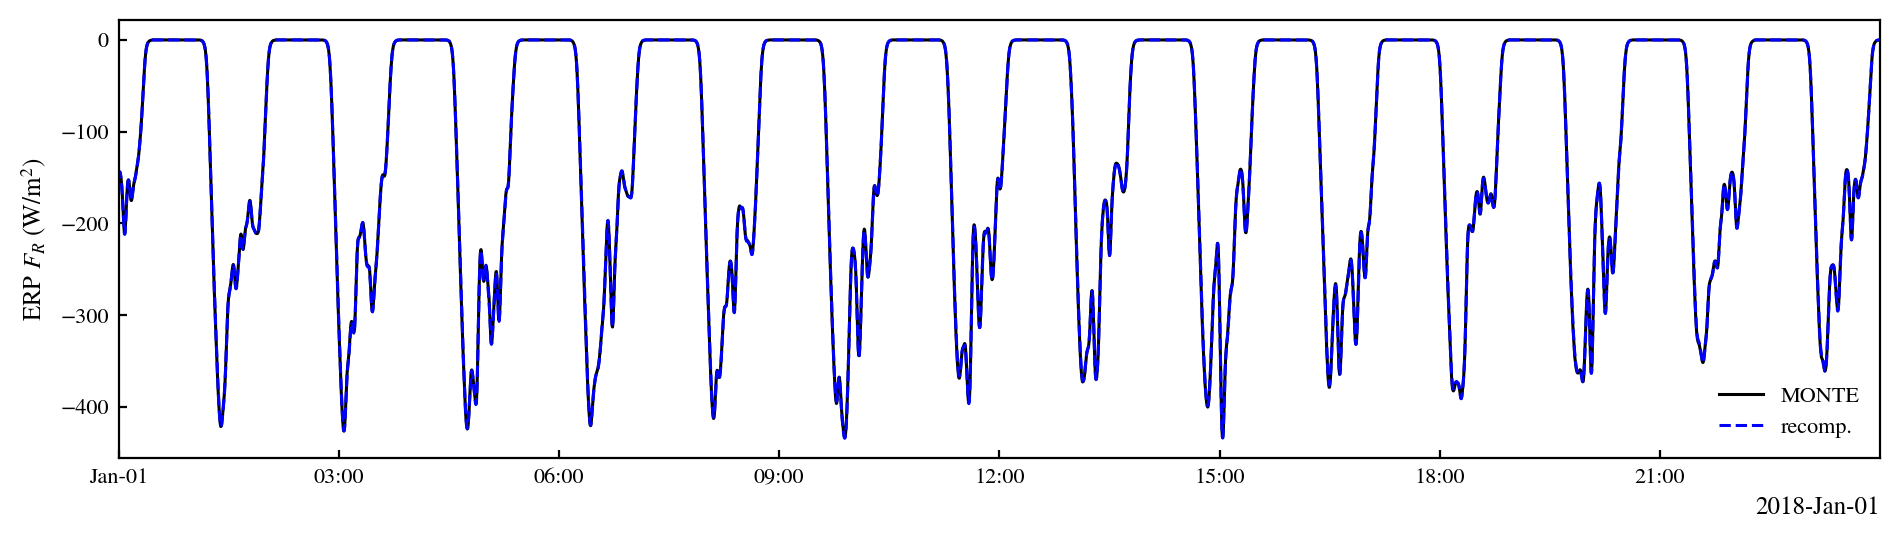

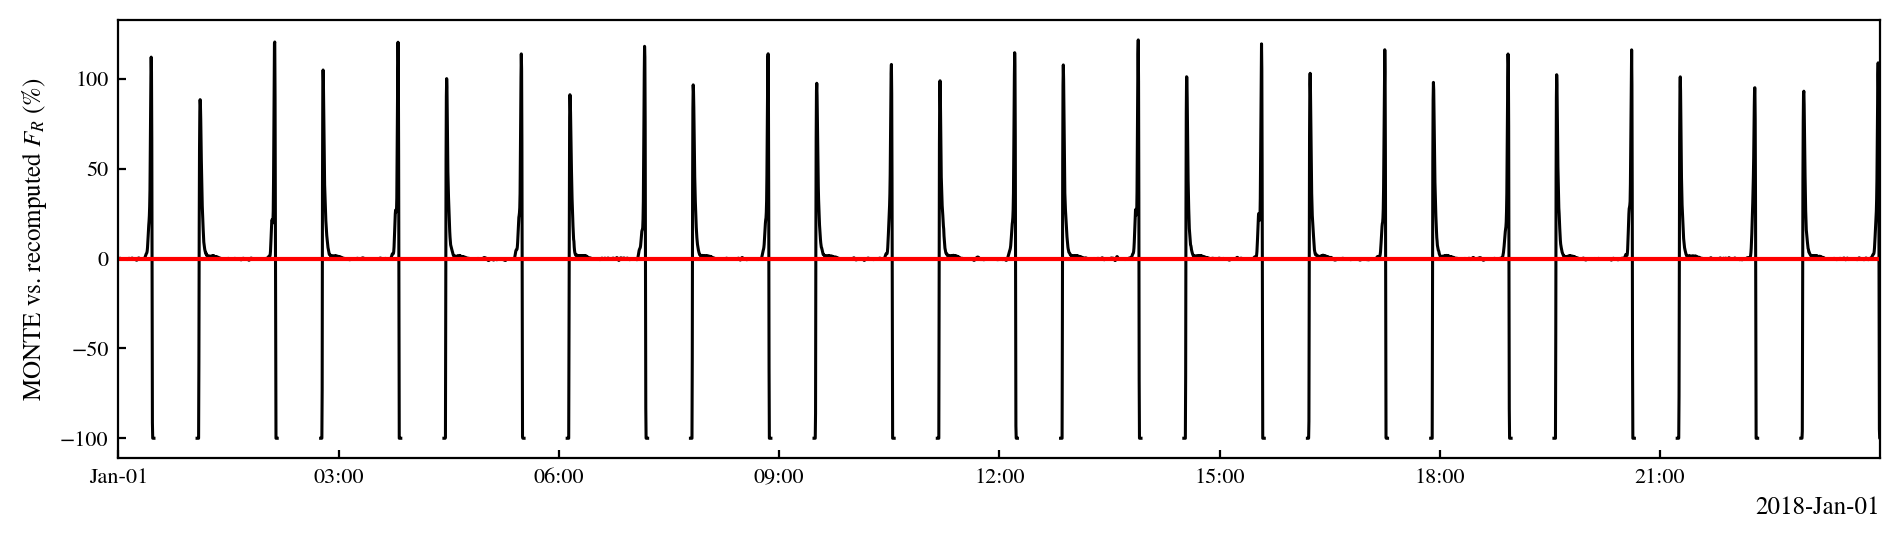

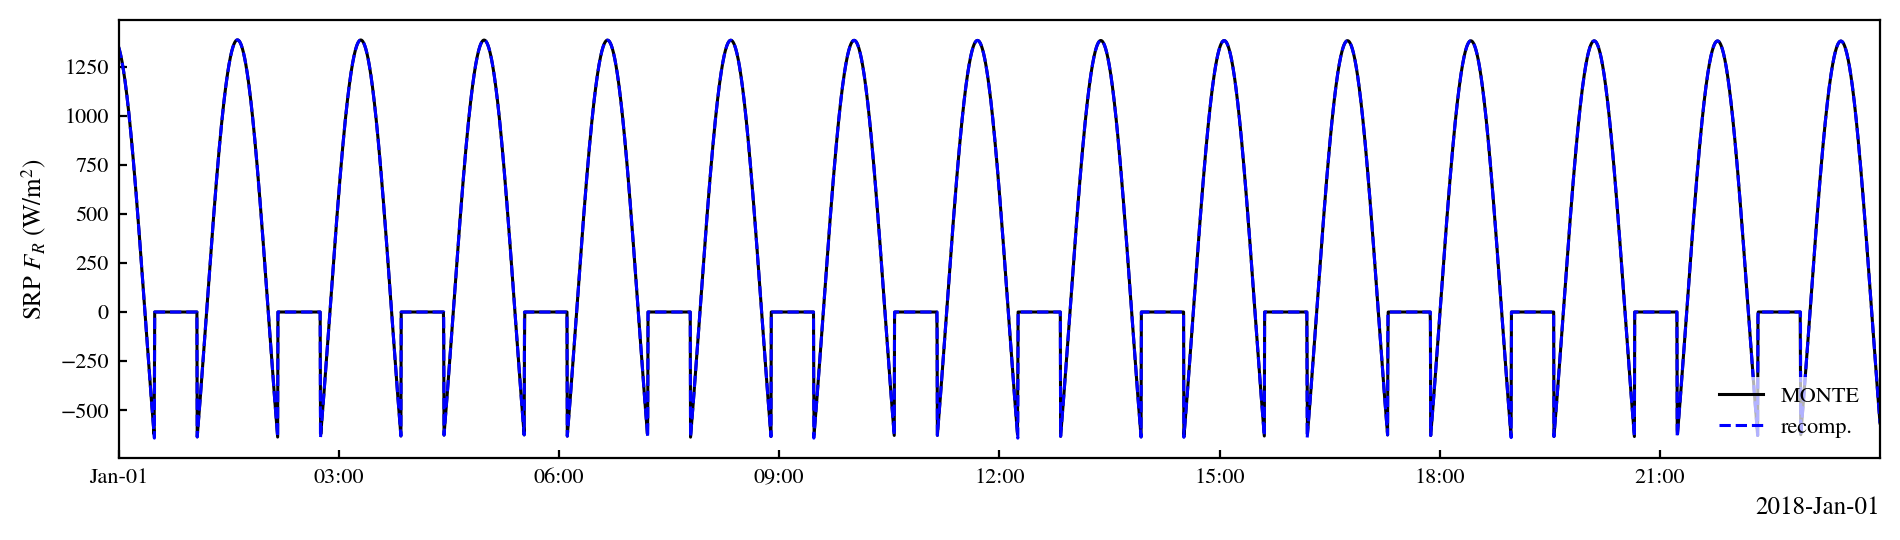

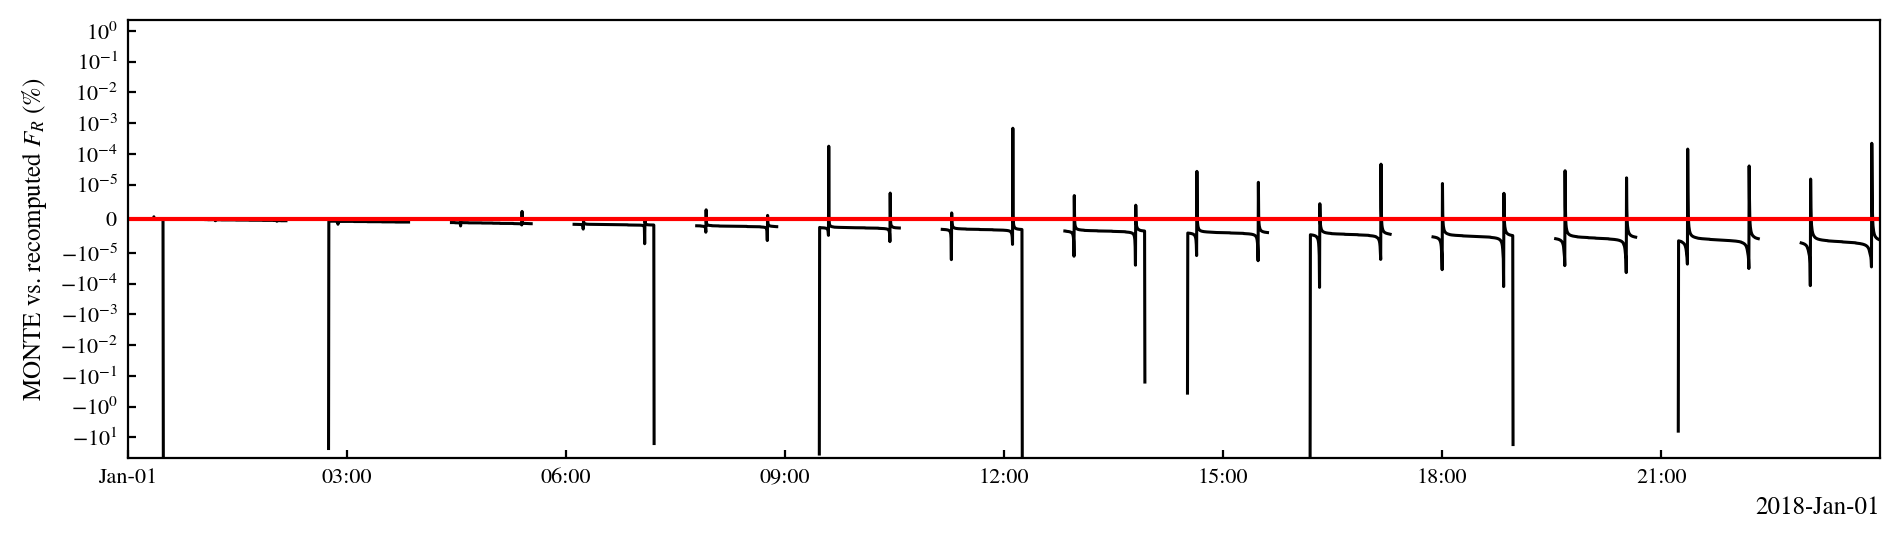

In [ ]:
import numpy as np
import sys, os
from SpaceBalls.postproc_EEI_estimation import get_acc_to_flux_factor, get_true_EEI_time_series, estimate_EEI_avg #, get_all_orbital_sma_0, get_stacked_avg_maps_3D_mode
from SpaceBalls.radiation_fluxes_preprocessing import compute_daily_hist_at_sat_r_hist, get_EEI_truth_daily_jd_arrays, get_mid_day_jd_array
from SpaceBalls.utils import normal_smoother, progress_bar, nanrms
import SpaceBalls.input_database_manager as input_manager
from SpaceBalls.sph_meshing import QuadratureGrid, KnockeGridMONTE, RegularLatLonGrid
from SpaceBalls.plotter import Plotter
import config.constants as constants
import itertools
import time
import random
from SpaceBalls.paths import CONFIG_DIR, MEDIA_DIR, INPUT_DIR, OUTPUT_DIR

grid = QuadratureGrid(0, order=325)
grid_knocke = KnockeGridMONTE(2)

grid_knocke_76 = KnockeGridMONTE(76)
grid_wom_190 = QuadratureGrid(0, order=189)
grid_glq_90 = RegularLatLonGrid(0, lmax=93, quad_type='GLQ')
print(grid_knocke_76.n_points)
print(grid_wom_190.n_points)
print(grid_glq_90.n_points)
grids_to_test = [grid_knocke_76] # grid_wom_190

time.sleep(1)

    

desired_sb = {
    'force_settings': 2,
    'integration_settings': 110,  # 0 for GRACE-FO_orbit
    'orbit_name': 'Ajisai_orbit', # 'GRACE-FO_orbit', # 'LAGEOS_orbit', #'GRACE-FO_orbit',
    'delta_t_out': 15,
}

keys = input_manager.get_primary_keys(desired_sb)
#keys = [key for key in keys if 'LAGEOS' not in key]
assert(len(keys)==1)
sb_tag = keys[0]

sb_tag = 'SB_R800_35_100'
#sb_tag = 'LAGEOS_119'

#sb_tag = 'ff616870cd0c6bdf' # '2151699c6e13c489' # 'bc67760fbec64597' #  #

EEI_truth = input_manager.get_dicts(sb_tag)['force_settings']['EEI_truth']
EEI_truth_name = 'EEI_truth_' + str(EEI_truth)

n_days = 1
start_idx = 0
day_idxs = range(start_idx, start_idx+n_days)
all_jd = [None] * n_days
all_diffs_erp = [None] * n_days
all_rel_diffs_erp = [None] * n_days
all_diffs_srp = [None] * n_days
all_rel_diffs_srp = [None] * n_days
all_erp = [None] * n_days
all_erp_recomp = [None] * n_days
all_srp = [None] * n_days
all_srp_recomp = [None] * n_days

for i, day_idx in enumerate(day_idxs):

    r_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'xyz_ecef.npy'))
    jd_hist_day = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'jd_vec.npy'))
    all_jd[i] = jd_hist_day

    erp_ar_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'erp.npy'))[:,0] * 1e3
    erp_Fr_hist = erp_ar_hist * get_acc_to_flux_factor(sb_tag)
    all_erp[i] = erp_Fr_hist

    srp_ar_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'srp.npy'))[:,0] * 1e3
    srp_Fr_hist = srp_ar_hist * get_acc_to_flux_factor(sb_tag)
    all_srp[i] = srp_Fr_hist

    recomp_erp_Fr_hist, recomp_srp_Fr_hist = compute_daily_hist_at_sat_r_hist(EEI_truth_name, #'EEI_truth_1', 
                                                             r_hist_day, jd_hist_day, 
                                                             day_idx, toa_grid=grid)

    for test_grid in grids_to_test:
        t1 = time.time()
        recomp_erp_Fr_hist_test, _ = compute_daily_hist_at_sat_r_hist(EEI_truth_name, #'EEI_truth_1', 
                                                                r_hist_day, jd_hist_day, 
                                                                day_idx, toa_grid=test_grid)
        t2 = time.time()    
        print(f"Time with {test_grid.grid_name}: {t2-t1}")

        diff = recomp_erp_Fr_hist_test - recomp_erp_Fr_hist
        rel_rms = nanrms(diff) / np.mean(recomp_erp_Fr_hist)
        print(f"Rel. RMS: {rel_rms}")

        bias = np.mean(diff)
        rel_bias = bias / np.mean(recomp_erp_Fr_hist)
        print(f"Rel. bias: {rel_bias}")


    #recomp_erp_Fr_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'erp_recomp_radial.npy'))* 1e3 * get_acc_to_flux_factor(sb_tag)
    #recomp_srp_Fr_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'day_'+str(day_idx), 'srp_recomp_radial.npy'))* 1e3 * get_acc_to_flux_factor(sb_tag)

    all_erp_recomp[i] = recomp_erp_Fr_hist
    print(recomp_erp_Fr_hist / get_acc_to_flux_factor(sb_tag))

    diff = erp_Fr_hist - recomp_erp_Fr_hist
    all_diffs_erp[i] = diff
    all_rel_diffs_erp[i] = diff / recomp_erp_Fr_hist

    all_srp_recomp[i] = recomp_srp_Fr_hist

    diff = srp_Fr_hist - recomp_srp_Fr_hist
    all_diffs_srp[i] = diff
    all_rel_diffs_srp[i] = diff / recomp_srp_Fr_hist


Plotter.plot_time_series(np.concatenate(all_jd), 
                         {'MONTE': np.concatenate(all_erp),
                          'recomp.': np.concatenate(all_erp_recomp),
                          },
                         ylabel='ERP $F_R$ (W/m$^2$)',
                         f_width=2.4, f_height=0.7)

Plotter.plot_time_series(np.concatenate(all_jd), 
                         {'Radial ERP': 100*np.concatenate(all_rel_diffs_erp)},
                         ylabel='MONTE vs. recomputed $F_R$ (%)',
                         f_width=2.4, f_height=0.7, zero_hline=True)

Plotter.plot_time_series(np.concatenate(all_jd), 
                         {'MONTE': np.concatenate(all_srp),
                          'recomp.': np.concatenate(all_srp_recomp),
                          },
                         ylabel='SRP $F_R$ (W/m$^2$)',
                         f_width=2.4, f_height=0.7)

Plotter.plot_time_series(np.concatenate(all_jd), 
                         {'Radial SRP': 100*np.concatenate(all_rel_diffs_srp)},
                         ylabel='MONTE vs. recomputed $F_R$ (%)',
                         f_width=2.4, f_height=0.7, yscale='symlog', linthresh=1e-5, zero_hline=True)


Computing daily hist TOA...
Expanding emissivity map (normalization unnorm)...
Evaluating a/e SH maps on TOA grid...
Expanding emissivity map (normalization unnorm)...
Computing step 1/5760
Computing step 2/5760
Computing step 3/5760
Computing step 4/5760
Computing step 5/5760
Computing step 6/5760
Computing step 7/5760
Computing step 8/5760
Computing step 9/5760
Computing step 10/5760
Computing step 11/5760
Computing step 12/5760
Computing step 13/5760
Computing step 14/5760
Computing step 15/5760
Computing step 16/5760
Computing step 17/5760
Computing step 18/5760
Computing step 19/5760
Computing step 20/5760
Computing step 21/5760
Computing step 22/5760
Computing step 23/5760
Computing step 24/5760
Computing step 25/5760
Computing step 26/5760
Computing step 27/5760
Computing step 28/5760
Computing step 29/5760
Computing step 30/5760
Computing step 31/5760
Computing step 32/5760
Computing step 33/5760
Computing step 34/5760
Computing step 35/5760
Computing step 36/5760
Computing ste

(<Figure size 1920x560 with 1 Axes>,
 <Axes: ylabel='ERP Leb.131 vs Wom.325 (W/m$^2$)'>)

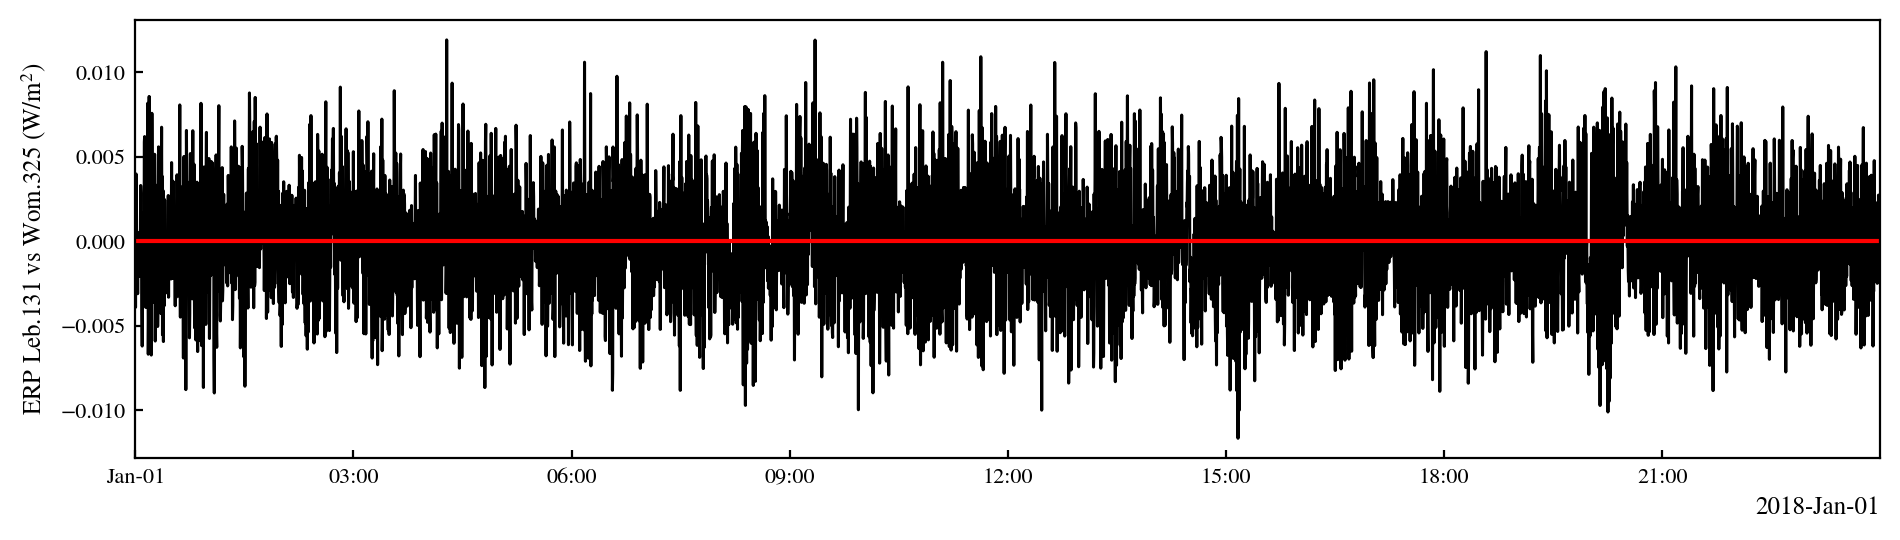

In [11]:
from SpaceBalls.sph_meshing import RegularLatLonGrid, QuadratureGrid

recomp_erp_Fr_131, _ = compute_daily_hist_at_sat_r_hist(EEI_truth_name, 
                                                             r_hist_day, jd_hist_day, 
                                                             day_idx,
                                                             toa_grid=QuadratureGrid(alt_km=0, order=131))

recomp_erp_Fr_325, _ = compute_daily_hist_at_sat_r_hist(EEI_truth_name, 
                                                             r_hist_day, jd_hist_day, 
                                                             day_idx,
                                                             toa_grid=QuadratureGrid(alt_km=0, order=325))

diff = recomp_erp_Fr_131 - recomp_erp_Fr_325

Plotter.plot_time_series(np.concatenate(all_jd), 
                         {'Radial ERP': diff},
                         ylabel='ERP Leb.131 vs Wom.325 (W/m$^2$)',
                         f_width=2.4, f_height=0.7, zero_hline=True)

In [ ]:
Plotter.plot_time_series(all_jd[0], 
                         {'Radial ERP': 100*diff/recomp_erp_Fr_325},
                         ylabel='ERP Leb.131 vs Wom.325 (%)',
                         f_width=2.4, f_height=0.7, zero_hline=True,
                         yscale='symlog', linthresh=1e-4)

In [ ]:
full_rel_diff = 100*np.concatenate(all_rel_diffs_srp)
full_rel_diff = full_rel_diff[recomp_srp_Fr_hist!=0]
np.nanmean(full_rel_diff)

In [ ]:
sb_tag = '5599f18be93e8561' #best:  #'bc67760fbec64597' # '2151699c6e13c489' # 'ff616870cd0c6bdf' #  #  #  #

full_recomp_erp_Fr_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'concatenated_erp_recomp_radial.npy'))* 1e3
full_erp_Fr_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'concatenated_erp.npy'))[:,0] * 1e3 
full_jd = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'concatenated_jd_vec.npy'))

diff = full_recomp_erp_Fr_hist - full_erp_Fr_hist
rel_diff = diff / full_recomp_erp_Fr_hist

Plotter.plot_time_series(full_jd, 
                         {'MONTE': full_erp_Fr_hist,
                          'recomp.': full_recomp_erp_Fr_hist,
                          },
                         ylabel='ERP $F_R$ (m/s$^2$)',
                         f_width=2.4, f_height=0.7)

Plotter.plot_time_series(full_jd, 
                         {'Radial ERP': 100*rel_diff},
                         ylabel='MONTE vs. recomputed $F_R$ (%)',
                         f_width=2.4, f_height=0.7)


In [ ]:
full_recomp_erp_Fr_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'concatenated_srp_recomp_radial.npy'))* 1e3
full_erp_Fr_hist = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'concatenated_srp.npy'))[:,0] * 1e3 
full_jd = np.load(os.path.join(OUTPUT_DIR, sb_tag, 'concatenated_jd_vec.npy'))

diff = full_recomp_erp_Fr_hist - full_erp_Fr_hist
rel_diff = diff / full_recomp_erp_Fr_hist

Plotter.plot_time_series(full_jd, 
                         {'MONTE': full_erp_Fr_hist,
                          'recomp.': full_recomp_erp_Fr_hist,
                          },
                         ylabel='SRP $F_R$ (m/s$^2$)',
                         f_width=2.4, f_height=0.7)

Plotter.plot_time_series(full_jd, 
                         {'Radial SRP': 100*rel_diff},
                         ylabel='MONTE vs. recomputed $F_R$ (%)',
                         f_width=2.4, f_height=0.7)


In [ ]:
Plotter.plot_time_series(full_jd[:30000], 
                         {'Radial SRP': 100*rel_diff[:30000]},
                         ylabel='MONTE vs. recomputed $F_R$ (%)',
                         f_width=2.4, f_height=0.7, yscale='symlog', linthresh=1e-5)

In [ ]:
np.argwhere(rel_diff>100)